In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [15]:
# 3. Load Dataset directly from Kaggle
# You will be asked for your Kaggle Username and Key.
# To get them: Go to Kaggle -> Settings -> API -> Create New Token -> Open the file
import sys
!{sys.executable} -m pip install opendatasets
import opendatasets as od
import pandas as pd
import os

# Download the dataset
dataset_url = "https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification"
od.download(dataset_url)

# Load the CSV (It downloads into a folder with the same name as the URL slug)
# Note: The file inside is named 'WELFake_Dataset.csv'
try:
    df = pd.read_csv('fake-news-classification/WELFake_Dataset.csv')
    print(f"Dataset Loaded Successfully! Shape: {df.shape}")
except FileNotFoundError:
    print("Error: Could not find the CSV. Check the folder name.")

Skipping, found downloaded files in "./fake-news-classification" (use force=True to force download)
Dataset Loaded Successfully! Shape: (72134, 4)


In [16]:
# Preprocessing
df = df.fillna('')
df['content'] = df['title'] + " " + df['text']

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

print("Cleaning text...")
df['content'] = df['content'].apply(clean_text)
print("Done.")

Cleaning text...
Done.


In [17]:
# Vectorization
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['content'])
y = df['label']

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
# Train Model
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      7006
           1       0.94      0.95      0.94      7421

    accuracy                           0.94     14427
   macro avg       0.94      0.94      0.94     14427
weighted avg       0.94      0.94      0.94     14427



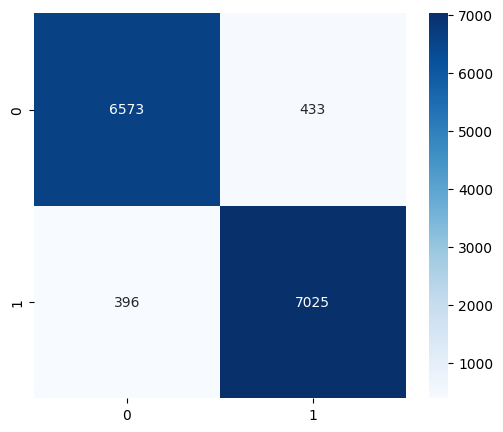

In [19]:
# Evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.show()

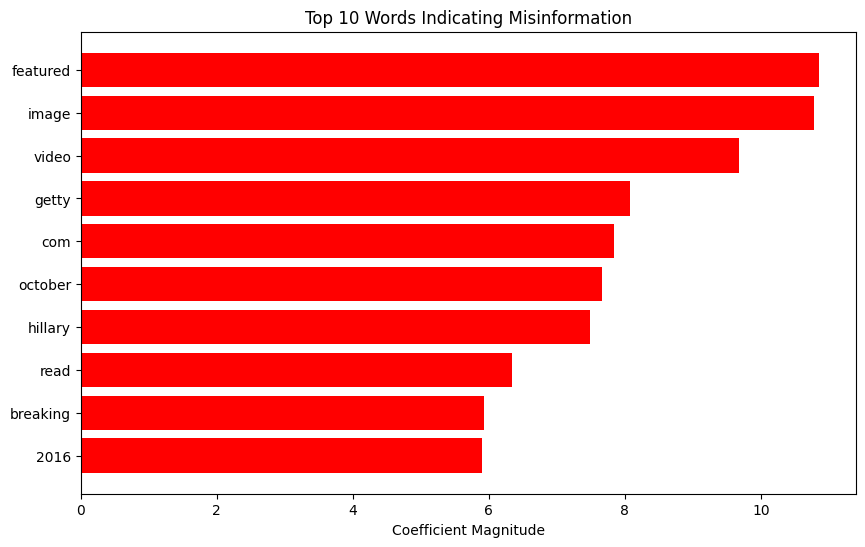

In [20]:
# Cell 7.5: Feature Importance (Crucial for Report)
# This generates the bar chart showing WHICH words imply "Fake News"
feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]
top_indices = np.argsort(coefs)[-10:] # Top 10 words for 'Fake'

plt.figure(figsize=(10,6))
plt.barh([feature_names[i] for i in top_indices], [coefs[i] for i in top_indices], color='red')
plt.title('Top 10 Words Indicating Misinformation')
plt.xlabel('Coefficient Magnitude')
plt.show()

In [21]:
# Save Artifacts
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

In [22]:
# Interactive Test Cell
# Run this cell, type a headline, and press Enter!

while True:
    user_input = input("Enter a news headline (or type 'exit' to stop): ")
    if user_input.lower() == 'exit':
        break

    # 1. Clean
    cleaned = clean_text(user_input)
    # 2. Vectorize
    vec_input = vectorizer.transform([cleaned])
    # 3. Predict
    pred = model.predict(vec_input)[0]
    prob = model.predict_proba(vec_input)[0]

    # 4. Result
    label = "FAKE NEWS" if pred == 1 else "REAL NEWS"
    confidence = round(max(prob) * 100, 2)

    print(f"\nResult: {label}")
    print(f"Confidence: {confidence}%\n" + "-"*30)

Enter a news headline (or type 'exit' to stop): Aliens found on Mars by NASA secret agent

Result: ⚠️ FAKE NEWS
Confidence: 93.43%
------------------------------
Enter a news headline (or type 'exit' to stop): Government announces new tax policy for small businesses

Result: ✅ REAL NEWS
Confidence: 71.49%
------------------------------
Enter a news headline (or type 'exit' to stop): LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter

Result: ⚠️ FAKE NEWS
Confidence: 98.88%
------------------------------
Enter a news headline (or type 'exit' to stop): In a recent press conference, the Mayor defended the city's decision to increase taxes, arguing that it is necessary to fund the failing school system. Critics, however, argue that the budget mismanagement has gone on for too long. While the debate continues, local business owners expressed concern that the new rates could force them to close. The City Council is expected to vote on the fina